# [SQL Full Course for Beginners (30 Hours) – From Zero to Hero](https://www.youtube.com/watch?v=SSKVgrwhzus)


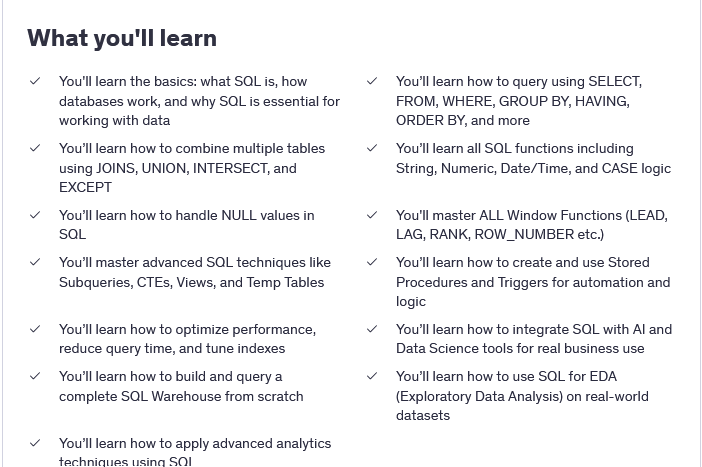 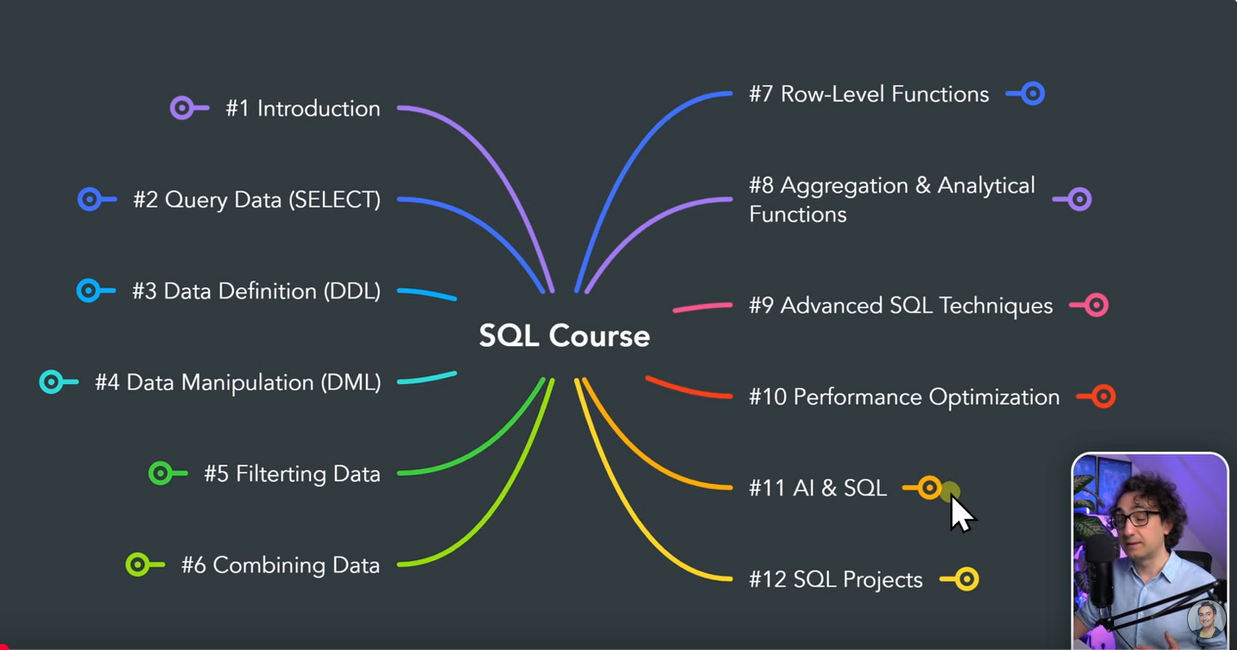

# Import required libraries

In [1]:
import pyodbc
import sys
sys.path.append("../..")
from utility.sql_utilities import SQLUtilities as ut

# Create Connection and Cursor for MyDatabase and SalesDB Databases

In [2]:
sqlserver_mydb_connector = pyodbc.connect("Driver={ODBC Driver 17 for SQL Server};" "Server=BRIGHT-WORK\\SQLEXPRESS;" "Database=MyDatabase;" "Trusted_Connection=yes;")
sqlserver_mydb_cursor = sqlserver_mydb_connector.cursor()

sqlserver_salesdb_connector = pyodbc.connect("Driver={ODBC Driver 17 for SQL Server};" "Server=BRIGHT-WORK\\SQLEXPRESS;" "Database=SalesDB;" "Trusted_Connection=yes;")
sqlserver_salesdb_cursor = sqlserver_salesdb_connector.cursor()

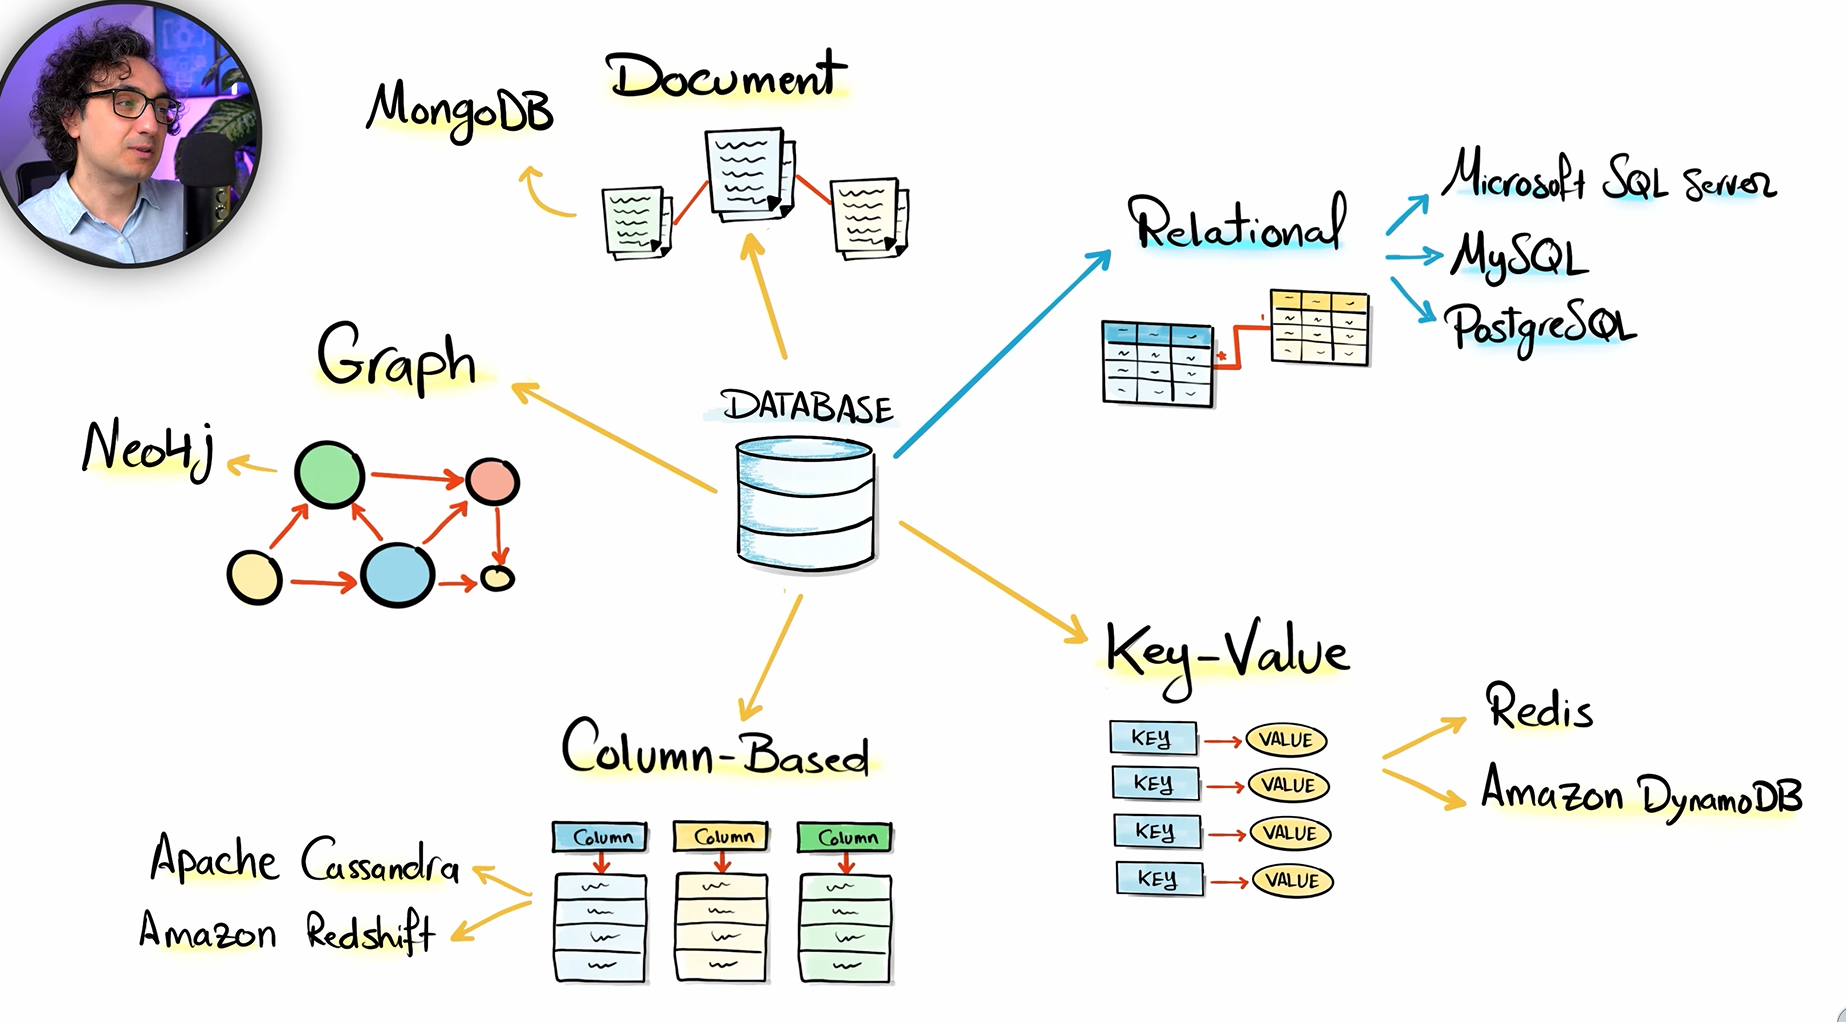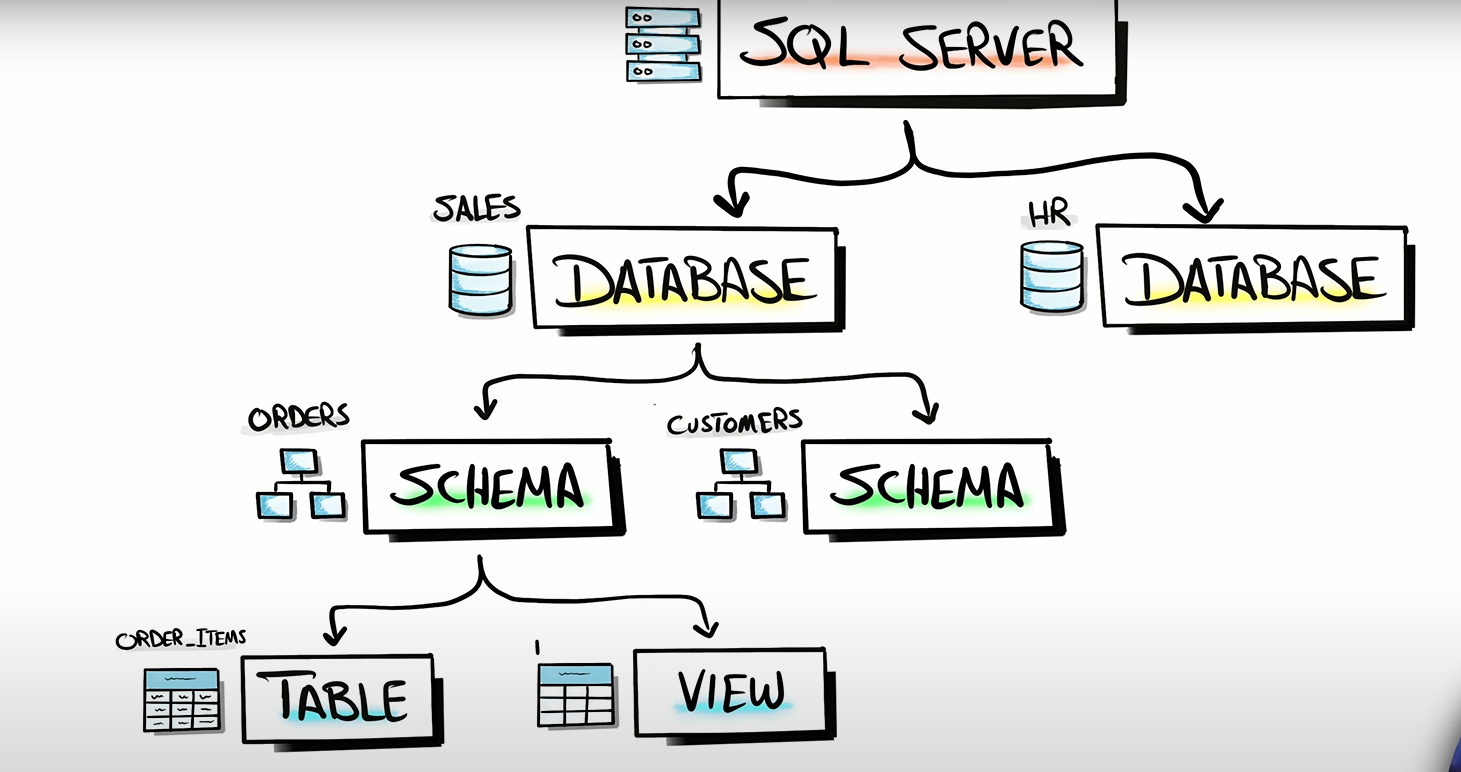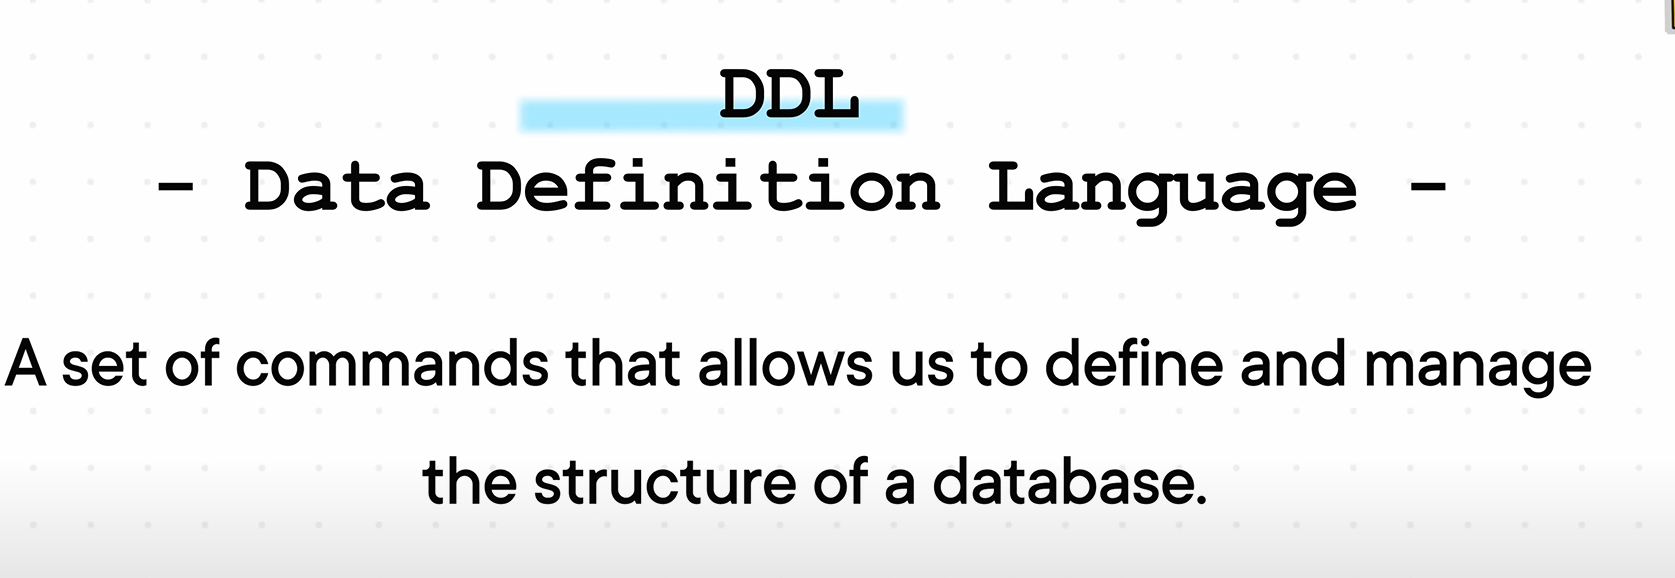
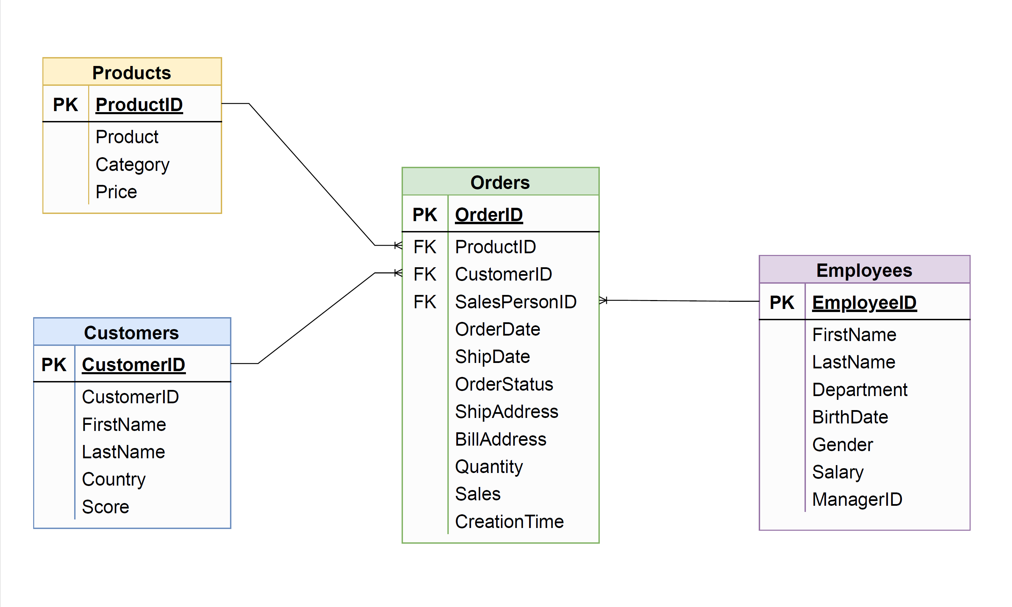

# Select 

In [3]:
ut.display_all_tables_in_database(cursor_object=sqlserver_mydb_cursor)

+---------------+--------------+------------+------------+
| TABLE_CATALOG | TABLE_SCHEMA | TABLE_NAME | TABLE_TYPE |
+---------------+--------------+------------+------------+
|  MyDatabase   |     dbo      | customers  | BASE TABLE |
|  MyDatabase   |     dbo      |   orders   | BASE TABLE |
+---------------+--------------+------------+------------+
2 rows returned in time: (0.036 sec)




In [4]:
# -- Retrieve All Customer Data
select_query: str = """
SELECT *
FROM customers
"""
ut.execute_display_query_results(query=select_query, cursor_object=sqlserver_mydb_cursor)

+----+------------+---------+-------+
| id | first_name | country | score |
+----+------------+---------+-------+
| 1  |   Maria    | Germany |  350  |
| 2  |    John    |   USA   |  900  |
| 3  |   Georg    |   UK    |  750  |
| 4  |   Martin   | Germany |  500  |
| 5  |   Peter    |   USA   |   0   |
+----+------------+---------+-------+
5 rows returned in time: (0.002 sec)




In [5]:
#-- Retrieve All Order Data
select_query: str = """
SELECT *
FROM orders
"""
ut.execute_display_query_results(query=select_query, cursor_object=sqlserver_mydb_cursor)

+----------+-------------+------------+-------+
| order_id | customer_id | order_date | sales |
+----------+-------------+------------+-------+
|   1001   |      1      | 2021-01-11 |  35   |
|   1002   |      2      | 2021-04-05 |  15   |
|   1003   |      3      | 2021-06-18 |  20   |
|   1004   |      6      | 2021-08-31 |  10   |
+----------+-------------+------------+-------+
4 rows returned in time: (0.013 sec)




# SELECT FEW COLUMNS

In [6]:
# -- Retrieve each customer's name, country, and score.
select_query: str = """
SELECT 
    first_name,
    country, 
    score
FROM customers
"""
ut.execute_display_query_results(query=select_query, cursor_object=sqlserver_mydb_cursor)

+------------+---------+-------+
| first_name | country | score |
+------------+---------+-------+
|   Maria    | Germany |  350  |
|    John    |   USA   |  900  |
|   Georg    |   UK    |  750  |
|   Martin   | Germany |  500  |
|   Peter    |   USA   |   0   |
+------------+---------+-------+
5 rows returned in time: (0.002 sec)




# WHERE

In [7]:
# -- Retrieve customers with a score not equal to 0
select_query: str = """
SELECT *
FROM customers
WHERE score != 0
"""
ut.execute_display_query_results(query=select_query, cursor_object=sqlserver_mydb_cursor)

+----+------------+---------+-------+
| id | first_name | country | score |
+----+------------+---------+-------+
| 1  |   Maria    | Germany |  350  |
| 2  |    John    |   USA   |  900  |
| 3  |   Georg    |   UK    |  750  |
| 4  |   Martin   | Germany |  500  |
+----+------------+---------+-------+
4 rows returned in time: (0.004 sec)




In [8]:
# -- Retrieve customers from Germany
select_query: str = """
SELECT *
FROM customers
WHERE country = 'Germany'
"""
ut.execute_display_query_results(query=select_query, cursor_object=sqlserver_mydb_cursor)

+----+------------+---------+-------+
| id | first_name | country | score |
+----+------------+---------+-------+
| 1  |   Maria    | Germany |  350  |
| 4  |   Martin   | Germany |  500  |
+----+------------+---------+-------+
2 rows returned in time: (0.001 sec)




In [9]:
# -- Retrieve the name and country of customers from Germany
select_query: str = """
SELECT
    first_name,
    country
FROM customers
WHERE country = 'Germany'
"""
ut.execute_display_query_results(query=select_query, cursor_object=sqlserver_mydb_cursor)

+------------+---------+
| first_name | country |
+------------+---------+
|   Maria    | Germany |
|   Martin   | Germany |
+------------+---------+
2 rows returned in time: (0.001 sec)




# ORDER BY

In [10]:
# -- Retrieve all customers and sort the results by the highest score first.
select_query: str = """
SELECT *
FROM customers
ORDER BY score DESC
"""
ut.execute_display_query_results(query=select_query, cursor_object=sqlserver_mydb_cursor)

+----+------------+---------+-------+
| id | first_name | country | score |
+----+------------+---------+-------+
| 2  |    John    |   USA   |  900  |
| 3  |   Georg    |   UK    |  750  |
| 4  |   Martin   | Germany |  500  |
| 1  |   Maria    | Germany |  350  |
| 5  |   Peter    |   USA   |   0   |
+----+------------+---------+-------+
5 rows returned in time: (0.002 sec)




In [11]:
# Retrieve all customers and sort the results by the lowest score first. 
select_query: str = """
SELECT *
FROM customers
ORDER BY score ASC
"""
ut.execute_display_query_results(query=select_query, cursor_object=sqlserver_mydb_cursor)

+----+------------+---------+-------+
| id | first_name | country | score |
+----+------------+---------+-------+
| 5  |   Peter    |   USA   |   0   |
| 1  |   Maria    | Germany |  350  |
| 4  |   Martin   | Germany |  500  |
| 3  |   Georg    |   UK    |  750  |
| 2  |    John    |   USA   |  900  |
+----+------------+---------+-------+
5 rows returned in time: (0.001 sec)




In [12]:
# Retrieve all customers and sort the results by the country.
select_query: str = """
SELECT *
FROM customers
ORDER BY country ASC
"""
ut.execute_display_query_results(query=select_query, cursor_object=sqlserver_mydb_cursor)

+----+------------+---------+-------+
| id | first_name | country | score |
+----+------------+---------+-------+
| 1  |   Maria    | Germany |  350  |
| 4  |   Martin   | Germany |  500  |
| 3  |   Georg    |   UK    |  750  |
| 5  |   Peter    |   USA   |   0   |
| 2  |    John    |   USA   |  900  |
+----+------------+---------+-------+
5 rows returned in time: (0.001 sec)




In [13]:
# Retrieve all customers and sort the results by the country and then by the highest score.
select_query: str = """
SELECT *
FROM customers
ORDER BY country ASC, score DESC
"""
ut.execute_display_query_results(query=select_query, cursor_object=sqlserver_mydb_cursor)

+----+------------+---------+-------+
| id | first_name | country | score |
+----+------------+---------+-------+
| 4  |   Martin   | Germany |  500  |
| 1  |   Maria    | Germany |  350  |
| 3  |   Georg    |   UK    |  750  |
| 2  |    John    |   USA   |  900  |
| 5  |   Peter    |   USA   |   0   |
+----+------------+---------+-------+
5 rows returned in time: (0.002 sec)




In [14]:
# Retrieve the name, country, and score of customers whose score is not equal to 0 and sort the results by the highest score first.
select_query: str = """
SELECT
    first_name,
    country,
    score
FROM customers
WHERE score != 0
ORDER BY score DESC
"""
ut.execute_display_query_results(query=select_query, cursor_object=sqlserver_mydb_cursor)

+------------+---------+-------+
| first_name | country | score |
+------------+---------+-------+
|    John    |   USA   |  900  |
|   Georg    |   UK    |  750  |
|   Martin   | Germany |  500  |
|   Maria    | Germany |  350  |
+------------+---------+-------+
4 rows returned in time: (0.006 sec)




# GROUP BY

In [15]:
# -- Find the total score for each country
select_query: str = """
SELECT 
    country,
    SUM(score) AS total_score
FROM customers
GROUP BY country
"""
ut.execute_display_query_results(query=select_query, cursor_object=sqlserver_mydb_cursor)

+---------+-------------+
| country | total_score |
+---------+-------------+
| Germany |     850     |
|   UK    |     750     |
|   USA   |     900     |
+---------+-------------+
3 rows returned in time: (0.003 sec)




In [16]:
# -- Find the total score and total number of customers for each country
select_query: str = """
SELECT 
    country,
    SUM(score) AS total_score,
    COUNT(id) AS total_customers
FROM customers
GROUP BY country;
"""
ut.execute_display_query_results(query=select_query, cursor_object=sqlserver_mydb_cursor)

+---------+-------------+-----------------+
| country | total_score | total_customers |
+---------+-------------+-----------------+
| Germany |     850     |        2        |
|   UK    |     750     |        1        |
|   USA   |     900     |        2        |
+---------+-------------+-----------------+
3 rows returned in time: (0.002 sec)




# Having

In [17]:
# Find the average score for each country and return only those countries with an average score greater than 430
select_query: str = """
SELECT
    country,
    AVG(score) AS avg_score
FROM customers
GROUP BY country
HAVING AVG(score) > 430;
"""
ut.execute_display_query_results(query=select_query, cursor_object=sqlserver_mydb_cursor)

+---------+-----------+
| country | avg_score |
+---------+-----------+
|   UK    |    750    |
|   USA   |    450    |
+---------+-----------+
2 rows returned in time: (0.007 sec)




In [18]:
# Find the average score for each country considering only customers with a score not equal to 0 and return only those countries with an average score greater than 430
select_query: str = """
SELECT
    country,
    AVG(score) AS avg_score
FROM customers
WHERE score != 0
GROUP BY country
HAVING AVG(score) > 430;
"""
ut.execute_display_query_results(query=select_query, cursor_object=sqlserver_mydb_cursor)

+---------+-----------+
| country | avg_score |
+---------+-----------+
|   UK    |    750    |
|   USA   |    900    |
+---------+-----------+
2 rows returned in time: (0.003 sec)




# DISTINCT

In [19]:
select_query: str = """
SELECT DISTINCT country
FROM customers;
"""
ut.execute_display_query_results(query=select_query, cursor_object=sqlserver_mydb_cursor)

+---------+
| country |
+---------+
| Germany |
|   UK    |
|   USA   |
+---------+
3 rows returned in time: (0.004 sec)




# Top

In [20]:
# -- Retrieve only 3 Customers
select_query: str = """
SELECT TOP 3 *
FROM customers
"""
ut.execute_display_query_results(query=select_query, cursor_object=sqlserver_mydb_cursor)

+----+------------+---------+-------+
| id | first_name | country | score |
+----+------------+---------+-------+
| 1  |   Maria    | Germany |  350  |
| 2  |    John    |   USA   |  900  |
| 3  |   Georg    |   UK    |  750  |
+----+------------+---------+-------+
3 rows returned in time: (0.001 sec)




In [21]:
# -- Retrieve the Top 3 Customers with the Highest Scores
select_query: str = """
SELECT TOP 3 *
FROM customers
ORDER BY score DESC
"""
ut.execute_display_query_results(query=select_query, cursor_object=sqlserver_mydb_cursor)

+----+------------+---------+-------+
| id | first_name | country | score |
+----+------------+---------+-------+
| 2  |    John    |   USA   |  900  |
| 3  |   Georg    |   UK    |  750  |
| 4  |   Martin   | Germany |  500  |
+----+------------+---------+-------+
3 rows returned in time: (0.001 sec)




In [22]:
# -- Retrieve the Lowest 2 Customers based on the score
select_query: str = """
SELECT TOP 2 *
FROM customers
ORDER BY score ASC;
"""
ut.execute_display_query_results(query=select_query, cursor_object=sqlserver_mydb_cursor)

+----+------------+---------+-------+
| id | first_name | country | score |
+----+------------+---------+-------+
| 5  |   Peter    |   USA   |   0   |
| 1  |   Maria    | Germany |  350  |
+----+------------+---------+-------+
2 rows returned in time: (0.003 sec)




In [23]:
# -- Retrieve the Lowest 2 Customers based on the score
select_query: str = """
SELECT TOP 2 *
FROM orders
ORDER BY order_date DESC;
"""
ut.execute_display_query_results(query=select_query, cursor_object=sqlserver_mydb_cursor)

+----------+-------------+------------+-------+
| order_id | customer_id | order_date | sales |
+----------+-------------+------------+-------+
|   1004   |      6      | 2021-08-31 |  10   |
|   1003   |      3      | 2021-06-18 |  20   |
+----------+-------------+------------+-------+
2 rows returned in time: (0.001 sec)




# All Together

In [24]:
"""
Calculate the average score for each country 
considering only customers with a score not equal to 0
and return only those countries with an average score greater than 430
and sort the results by the highest average score first.
"""
select_query: str = """
SELECT
    country,
    AVG(score) AS avg_score
FROM customers
WHERE score != 0
GROUP BY country
HAVING AVG(score) > 430
ORDER BY AVG(score) DESC;
"""
ut.execute_display_query_results(query=select_query, cursor_object=sqlserver_mydb_cursor)

+---------+-----------+
| country | avg_score |
+---------+-----------+
|   USA   |    900    |
|   UK    |    750    |
+---------+-----------+
2 rows returned in time: (0.006 sec)




# Create 

In [25]:
"""
Create a new table called persons 
with columns: id, person_name, birth_date, and phone
"""
ut.execute_query(query="""DROP TABLE IF EXISTS persons""", cursor_object=sqlserver_mydb_cursor)

create_query: str = """
CREATE TABLE persons (
    id INT NOT NULL,
    person_name VARCHAR(50) NOT NULL,
    birth_date DATE,
    phone VARCHAR(15) NOT NULL,
    CONSTRAINT pk_persons PRIMARY KEY (id)
);
"""
ut.execute_query(query=create_query, cursor_object=sqlserver_mydb_cursor)

ut.display_all_tables_in_database(cursor_object=sqlserver_mydb_cursor)

ut.show_columns(table_name='persons', cursor_object=sqlserver_mydb_cursor)

Query ran successfully in time: (0.001 sec)
Query ran successfully in time: (0.024 sec)
+---------------+--------------+------------+------------+
| TABLE_CATALOG | TABLE_SCHEMA | TABLE_NAME | TABLE_TYPE |
+---------------+--------------+------------+------------+
|  MyDatabase   |     dbo      | customers  | BASE TABLE |
|  MyDatabase   |     dbo      |   orders   | BASE TABLE |
|  MyDatabase   |     dbo      |  persons   | BASE TABLE |
+---------------+--------------+------------+------------+
3 rows returned in time: (0.003 sec)


+-------------+----------------+-------------+-----------+---------------+--------------+
| column_name | column_default | is_nullable | data_type | table_catalog | table_schema |
+-------------+----------------+-------------+-----------+---------------+--------------+
|     id      |      NULL      |     NO      |    int    |  MyDatabase   |     dbo      |
| person_name |      NULL      |     NO      |  varchar  |  MyDatabase   |     dbo      |
| birth_da

In [26]:
ut.show_columns(table_name='persons', cursor_object=sqlserver_mydb_cursor)

+-------------+----------------+-------------+-----------+---------------+--------------+
| column_name | column_default | is_nullable | data_type | table_catalog | table_schema |
+-------------+----------------+-------------+-----------+---------------+--------------+
|     id      |      NULL      |     NO      |    int    |  MyDatabase   |     dbo      |
| person_name |      NULL      |     NO      |  varchar  |  MyDatabase   |     dbo      |
| birth_date  |      NULL      |     YES     |   date    |  MyDatabase   |     dbo      |
|    phone    |      NULL      |     NO      |  varchar  |  MyDatabase   |     dbo      |
+-------------+----------------+-------------+-----------+---------------+--------------+
4 rows returned in time: (0.001 sec)




# Alter

In [27]:
alter_query: str = """
ALTER TABLE persons
ADD email VARCHAR(50) NOT NULL;
"""
ut.execute_query(query=alter_query, cursor_object=sqlserver_mydb_cursor)

ut.show_columns(table_name='persons', cursor_object=sqlserver_mydb_cursor)

Query ran successfully in time: (0.01 sec)
+-------------+----------------+-------------+-----------+---------------+--------------+
| column_name | column_default | is_nullable | data_type | table_catalog | table_schema |
+-------------+----------------+-------------+-----------+---------------+--------------+
|     id      |      NULL      |     NO      |    int    |  MyDatabase   |     dbo      |
| person_name |      NULL      |     NO      |  varchar  |  MyDatabase   |     dbo      |
| birth_date  |      NULL      |     YES     |   date    |  MyDatabase   |     dbo      |
|    phone    |      NULL      |     NO      |  varchar  |  MyDatabase   |     dbo      |
|    email    |      NULL      |     NO      |  varchar  |  MyDatabase   |     dbo      |
+-------------+----------------+-------------+-----------+---------------+--------------+
5 rows returned in time: (0.001 sec)




# DROP 

In [28]:
drop_query: str = """
ALTER TABLE persons
DROP COLUMN phone;
"""
ut.execute_query(query=drop_query, cursor_object=sqlserver_mydb_cursor)

ut.show_columns(table_name='persons', cursor_object=sqlserver_mydb_cursor)

Query ran successfully in time: (0.002 sec)
+-------------+----------------+-------------+-----------+---------------+--------------+
| column_name | column_default | is_nullable | data_type | table_catalog | table_schema |
+-------------+----------------+-------------+-----------+---------------+--------------+
|     id      |      NULL      |     NO      |    int    |  MyDatabase   |     dbo      |
| person_name |      NULL      |     NO      |  varchar  |  MyDatabase   |     dbo      |
| birth_date  |      NULL      |     YES     |   date    |  MyDatabase   |     dbo      |
|    email    |      NULL      |     NO      |  varchar  |  MyDatabase   |     dbo      |
+-------------+----------------+-------------+-----------+---------------+--------------+
4 rows returned in time: (0.0 sec)




In [29]:
ut.execute_query(query="DROP TABLE persons;", cursor_object=sqlserver_mydb_cursor)
ut.show_columns(table_name='persons', cursor_object=sqlserver_mydb_cursor)

Query ran successfully in time: (0.002 sec)
+-------------+----------------+-------------+-----------+---------------+--------------+
| column_name | column_default | is_nullable | data_type | table_catalog | table_schema |
+-------------+----------------+-------------+-----------+---------------+--------------+
+-------------+----------------+-------------+-----------+---------------+--------------+
0 rows returned in time: (0.001 sec)




# SQL Data Manipulation Language (DML)

## Insert 

In [30]:
ut.select_all_query(table_name='customers', cursor_object=sqlserver_mydb_cursor)

insert_query: str = """
INSERT INTO customers (id, first_name, country, score)
VALUES 
    (6, 'Anna', 'USA', NULL),
    (7, 'Sam', NULL, 100)
"""
ut.execute_query(query=insert_query, cursor_object=sqlserver_mydb_cursor)

ut.select_all_query(table_name='customers', cursor_object=sqlserver_mydb_cursor)

+----+------------+---------+-------+
| id | first_name | country | score |
+----+------------+---------+-------+
| 1  |   Maria    | Germany |  350  |
| 2  |    John    |   USA   |  900  |
| 3  |   Georg    |   UK    |  750  |
| 4  |   Martin   | Germany |  500  |
| 5  |   Peter    |   USA   |   0   |
+----+------------+---------+-------+
5 rows returned in time: (0.001 sec)


Query ran successfully in time: (0.002 sec)
+----+------------+---------+-------+
| id | first_name | country | score |
+----+------------+---------+-------+
| 1  |   Maria    | Germany |  350  |
| 2  |    John    |   USA   |  900  |
| 3  |   Georg    |   UK    |  750  |
| 4  |   Martin   | Germany |  500  |
| 5  |   Peter    |   USA   |   0   |
| 6  |    Anna    |   USA   | NULL  |
| 7  |    Sam     |  NULL   |  100  |
+----+------------+---------+-------+
7 rows returned in time: (0.0 sec)




In [31]:
insert_query: str = """
-- Insert a new record with full column values
INSERT INTO customers (id, first_name, country, score)
VALUES (8, 'Max', 'USA', 368)
"""
ut.execute_query(query=insert_query, cursor_object=sqlserver_mydb_cursor)

ut.select_all_query(table_name='customers', cursor_object=sqlserver_mydb_cursor)

Query ran successfully in time: (0.002 sec)
+----+------------+---------+-------+
| id | first_name | country | score |
+----+------------+---------+-------+
| 1  |   Maria    | Germany |  350  |
| 2  |    John    |   USA   |  900  |
| 3  |   Georg    |   UK    |  750  |
| 4  |   Martin   | Germany |  500  |
| 5  |   Peter    |   USA   |   0   |
| 6  |    Anna    |   USA   | NULL  |
| 7  |    Sam     |  NULL   |  100  |
| 8  |    Max     |   USA   |  368  |
+----+------------+---------+-------+
8 rows returned in time: (0.001 sec)




In [32]:
insert_query: str = """
-- Insert a new record without specifying column names (not recommended)
INSERT INTO customers 
VALUES (9, 'Andreas', 'Germany', NULL)
"""
ut.execute_query(query=insert_query, cursor_object=sqlserver_mydb_cursor)

ut.select_all_query(table_name='customers', cursor_object=sqlserver_mydb_cursor)

Query ran successfully in time: (0.001 sec)
+----+------------+---------+-------+
| id | first_name | country | score |
+----+------------+---------+-------+
| 1  |   Maria    | Germany |  350  |
| 2  |    John    |   USA   |  900  |
| 3  |   Georg    |   UK    |  750  |
| 4  |   Martin   | Germany |  500  |
| 5  |   Peter    |   USA   |   0   |
| 6  |    Anna    |   USA   | NULL  |
| 7  |    Sam     |  NULL   |  100  |
| 8  |    Max     |   USA   |  368  |
| 9  |  Andreas   | Germany | NULL  |
+----+------------+---------+-------+
9 rows returned in time: (0.001 sec)




In [33]:
ut.show_columns(table_name='persons', cursor_object=sqlserver_mydb_cursor)

+-------------+----------------+-------------+-----------+---------------+--------------+
| column_name | column_default | is_nullable | data_type | table_catalog | table_schema |
+-------------+----------------+-------------+-----------+---------------+--------------+
+-------------+----------------+-------------+-----------+---------------+--------------+
0 rows returned in time: (0.0 sec)




In [34]:
create_query: str = """
CREATE TABLE persons (
    id INT NOT NULL,
    person_name VARCHAR(50) NOT NULL,
    birth_date DATE,
    phone VARCHAR(15) NOT NULL,
    CONSTRAINT pk_persons PRIMARY KEY (id)
);
"""
ut.execute_query(query=create_query, cursor_object=sqlserver_mydb_cursor)
ut.select_all_query(table_name='persons', cursor_object=sqlserver_mydb_cursor)

insert_query: str = """
-- Insert a new record without specifying column names (not recommended)
INSERT INTO persons (id, person_name, birth_date, phone)
SELECT
    id,
    first_name,
    NULL,
    'Unknown'
FROM customers
"""
ut.execute_query(query=insert_query, cursor_object=sqlserver_mydb_cursor)
ut.select_all_query(table_name='persons', cursor_object=sqlserver_mydb_cursor)

Query ran successfully in time: (0.006 sec)
+----+-------------+------------+-------+
| id | person_name | birth_date | phone |
+----+-------------+------------+-------+
+----+-------------+------------+-------+
0 rows returned in time: (0.001 sec)


Query ran successfully in time: (0.014 sec)
+----+-------------+------------+---------+
| id | person_name | birth_date |  phone  |
+----+-------------+------------+---------+
| 1  |    Maria    |    NULL    | Unknown |
| 2  |     John    |    NULL    | Unknown |
| 3  |    Georg    |    NULL    | Unknown |
| 4  |   Martin    |    NULL    | Unknown |
| 5  |    Peter    |    NULL    | Unknown |
| 6  |    Anna     |    NULL    | Unknown |
| 7  |     Sam     |    NULL    | Unknown |
| 8  |     Max     |    NULL    | Unknown |
| 9  |   Andreas   |    NULL    | Unknown |
+----+-------------+------------+---------+
9 rows returned in time: (0.0 sec)




## Update

In [35]:
ut.select_all_query(table_name='customers', cursor_object=sqlserver_mydb_cursor)
update_query: str = """
-- Change the score of customer with ID 6 to 0
UPDATE customers
SET score = 0
WHERE id = 6
"""
ut.execute_query(query=update_query, cursor_object=sqlserver_mydb_cursor)
ut.select_all_query(table_name='customers', cursor_object=sqlserver_mydb_cursor)

+----+------------+---------+-------+
| id | first_name | country | score |
+----+------------+---------+-------+
| 1  |   Maria    | Germany |  350  |
| 2  |    John    |   USA   |  900  |
| 3  |   Georg    |   UK    |  750  |
| 4  |   Martin   | Germany |  500  |
| 5  |   Peter    |   USA   |   0   |
| 6  |    Anna    |   USA   | NULL  |
| 7  |    Sam     |  NULL   |  100  |
| 8  |    Max     |   USA   |  368  |
| 9  |  Andreas   | Germany | NULL  |
+----+------------+---------+-------+
9 rows returned in time: (0.001 sec)


Query ran successfully in time: (0.004 sec)
+----+------------+---------+-------+
| id | first_name | country | score |
+----+------------+---------+-------+
| 1  |   Maria    | Germany |  350  |
| 2  |    John    |   USA   |  900  |
| 3  |   Georg    |   UK    |  750  |
| 4  |   Martin   | Germany |  500  |
| 5  |   Peter    |   USA   |   0   |
| 6  |    Anna    |   USA   |   0   |
| 7  |    Sam     |  NULL   |  100  |
| 8  |    Max     |   USA   |  368  |
| 9  

In [36]:
ut.select_all_query(table_name='customers', cursor_object=sqlserver_mydb_cursor)
update_query: str = """
-- Change the score of customer with ID 10 to 0 and update the country to 'UK'
UPDATE customers
SET score = 0,
    country = 'UK'
WHERE id = 10
"""
ut.execute_query(query=update_query, cursor_object=sqlserver_mydb_cursor)
ut.select_all_query(table_name='customers', cursor_object=sqlserver_mydb_cursor)

+----+------------+---------+-------+
| id | first_name | country | score |
+----+------------+---------+-------+
| 1  |   Maria    | Germany |  350  |
| 2  |    John    |   USA   |  900  |
| 3  |   Georg    |   UK    |  750  |
| 4  |   Martin   | Germany |  500  |
| 5  |   Peter    |   USA   |   0   |
| 6  |    Anna    |   USA   |   0   |
| 7  |    Sam     |  NULL   |  100  |
| 8  |    Max     |   USA   |  368  |
| 9  |  Andreas   | Germany | NULL  |
+----+------------+---------+-------+
9 rows returned in time: (0.001 sec)


Query ran successfully in time: (0.001 sec)
+----+------------+---------+-------+
| id | first_name | country | score |
+----+------------+---------+-------+
| 1  |   Maria    | Germany |  350  |
| 2  |    John    |   USA   |  900  |
| 3  |   Georg    |   UK    |  750  |
| 4  |   Martin   | Germany |  500  |
| 5  |   Peter    |   USA   |   0   |
| 6  |    Anna    |   USA   |   0   |
| 7  |    Sam     |  NULL   |  100  |
| 8  |    Max     |   USA   |  368  |
| 9  

In [37]:
update_query: str = """
-- Update all customers with a NULL score by setting their score to 0
UPDATE customers
SET score = 0
WHERE score IS NULL
"""
ut.execute_query(query=update_query, cursor_object=sqlserver_mydb_cursor)
ut.select_all_query(table_name='customers', cursor_object=sqlserver_mydb_cursor)

Query ran successfully in time: (0.002 sec)
+----+------------+---------+-------+
| id | first_name | country | score |
+----+------------+---------+-------+
| 1  |   Maria    | Germany |  350  |
| 2  |    John    |   USA   |  900  |
| 3  |   Georg    |   UK    |  750  |
| 4  |   Martin   | Germany |  500  |
| 5  |   Peter    |   USA   |   0   |
| 6  |    Anna    |   USA   |   0   |
| 7  |    Sam     |  NULL   |  100  |
| 8  |    Max     |   USA   |  368  |
| 9  |  Andreas   | Germany |   0   |
+----+------------+---------+-------+
9 rows returned in time: (0.0 sec)




In [38]:
select_query: str = """
-- Verify the update
SELECT *
FROM customers
WHERE score IS NULL
"""
ut.execute_display_query_results(query=select_query, cursor_object=sqlserver_mydb_cursor)

+----+------------+---------+-------+
| id | first_name | country | score |
+----+------------+---------+-------+
+----+------------+---------+-------+
0 rows returned in time: (0.004 sec)




## Delete

In [39]:
ut.select_all_query(table_name='customers', cursor_object=sqlserver_mydb_cursor)

select_query: str = """
-- Select customers with an ID greater than 5 before deleting
SELECT *
FROM customers
WHERE id > 5
"""
ut.execute_display_query_results(query=select_query, cursor_object=sqlserver_mydb_cursor)

delete_query: str = """
-- Delete all customers with an ID greater than 5
DELETE FROM customers
WHERE id > 5
"""
ut.execute_query(query=delete_query, cursor_object=sqlserver_mydb_cursor)

ut.select_all_query(table_name='customers', cursor_object=sqlserver_mydb_cursor)

+----+------------+---------+-------+
| id | first_name | country | score |
+----+------------+---------+-------+
| 1  |   Maria    | Germany |  350  |
| 2  |    John    |   USA   |  900  |
| 3  |   Georg    |   UK    |  750  |
| 4  |   Martin   | Germany |  500  |
| 5  |   Peter    |   USA   |   0   |
| 6  |    Anna    |   USA   |   0   |
| 7  |    Sam     |  NULL   |  100  |
| 8  |    Max     |   USA   |  368  |
| 9  |  Andreas   | Germany |   0   |
+----+------------+---------+-------+
9 rows returned in time: (0.001 sec)


+----+------------+---------+-------+
| id | first_name | country | score |
+----+------------+---------+-------+
| 6  |    Anna    |   USA   |   0   |
| 7  |    Sam     |  NULL   |  100  |
| 8  |    Max     |   USA   |  368  |
| 9  |  Andreas   | Germany |   0   |
+----+------------+---------+-------+
4 rows returned in time: (0.003 sec)


Query ran successfully in time: (0.001 sec)
+----+------------+---------+-------+
| id | first_name | country | score |
+---

In [40]:
ut.select_all_query(table_name='persons', cursor_object=sqlserver_mydb_cursor)
ut.execute_query(query="TRUNCATE TABLE persons", cursor_object=sqlserver_mydb_cursor)
ut.select_all_query(table_name='persons', cursor_object=sqlserver_mydb_cursor)

+----+-------------+------------+---------+
| id | person_name | birth_date |  phone  |
+----+-------------+------------+---------+
| 1  |    Maria    |    NULL    | Unknown |
| 2  |     John    |    NULL    | Unknown |
| 3  |    Georg    |    NULL    | Unknown |
| 4  |   Martin    |    NULL    | Unknown |
| 5  |    Peter    |    NULL    | Unknown |
| 6  |    Anna     |    NULL    | Unknown |
| 7  |     Sam     |    NULL    | Unknown |
| 8  |     Max     |    NULL    | Unknown |
| 9  |   Andreas   |    NULL    | Unknown |
+----+-------------+------------+---------+
9 rows returned in time: (0.0 sec)


Query ran successfully in time: (0.001 sec)
+----+-------------+------------+-------+
| id | person_name | birth_date | phone |
+----+-------------+------------+-------+
+----+-------------+------------+-------+
0 rows returned in time: (0.003 sec)


